# TUTORIAL: the `dynamodels` Model class

* [How to use the class Model in `dynamodels.physical`](#first)
    * [Model initialization](#second)
    * [Model forecast](#third)
* [Ensembles of a Model](#fourth)
    * [Ensemble initialization](#fifth)
    * [Ensemble forecast](#sixth)
    * [Visualizing the ensemble](#seventh)


# How to use the class `Model` <a class="anchor" id="first"></a>

### 1. Initialise a model from `dynamodels.physical` using the default parameters  <a class="anchor" id="second"></a>
The available models are:
* Lorenz63
* Rijke
* Annular
* Van der Pol
* Kuramoto-Sivashinsky
* Lorenz96

Under the hood every `Model` composes two pieces: a `HistoryTracker` (the pre-allocated, grow-on-demand state/time buffer behind `hist`, `hist_t`, `current_state` and `update_history()`) and an `Integrator` strategy — continuous models define `time_derivative(t, psi, **params)` and are advanced with scipy's `solve_ivp`, while discrete maps (e.g. Kuramoto-Sivashinsky) define `time_step(Nt)` directly.

Data-driven models (ESN, POD-ESN) implementing the same interface live in the [romda](https://github.com/andreanovoa/real-time-bias-aware-DA) package.


In [ ]:
from dynamodels.physical import Kuznetsov as TheModel

case = TheModel()  # If no arguments, the class is initialized with the default parameters


### 2. Forecast the model as a single case  <a class="anchor" id="third"></a>

The forecast of the model is taken care by the `Integrator` class. Different models use different integrators:
- `<class 'integrator.IVPIntegrator'>`: models defined in state-space form as intial value problems (e.g, Rijke, Lorenz63, VdP)

    $\dfrac{d \psi}{d t} = F(\psi, t, x)$
- `<class 'integrator.DiscreteIntegrator'>`: models with discrete time stepping (e.g, ESN, KS)

    $\psi(t+\Delta t) = \psi(t) + G(\psi(t))\Delta t$



In [15]:
print(f'Model {case.__class__.__name__} uses {case.integrator.__class__.__name__} for time integration.')

Model KS2D uses DiscreteIntegrator for time integration.


In [16]:
import time

Nt_forecast = int( case.t_transient / case.dt)

t1 = time.time()
state, t_ = case.time_integrate(Nt_forecast)
case.update_history(state[1:], t_[1:], reset=True)

single_case_time = time.time() - t1
print('Elapsed time = ', str(single_case_time))



Elapsed time =  13.60335087776184


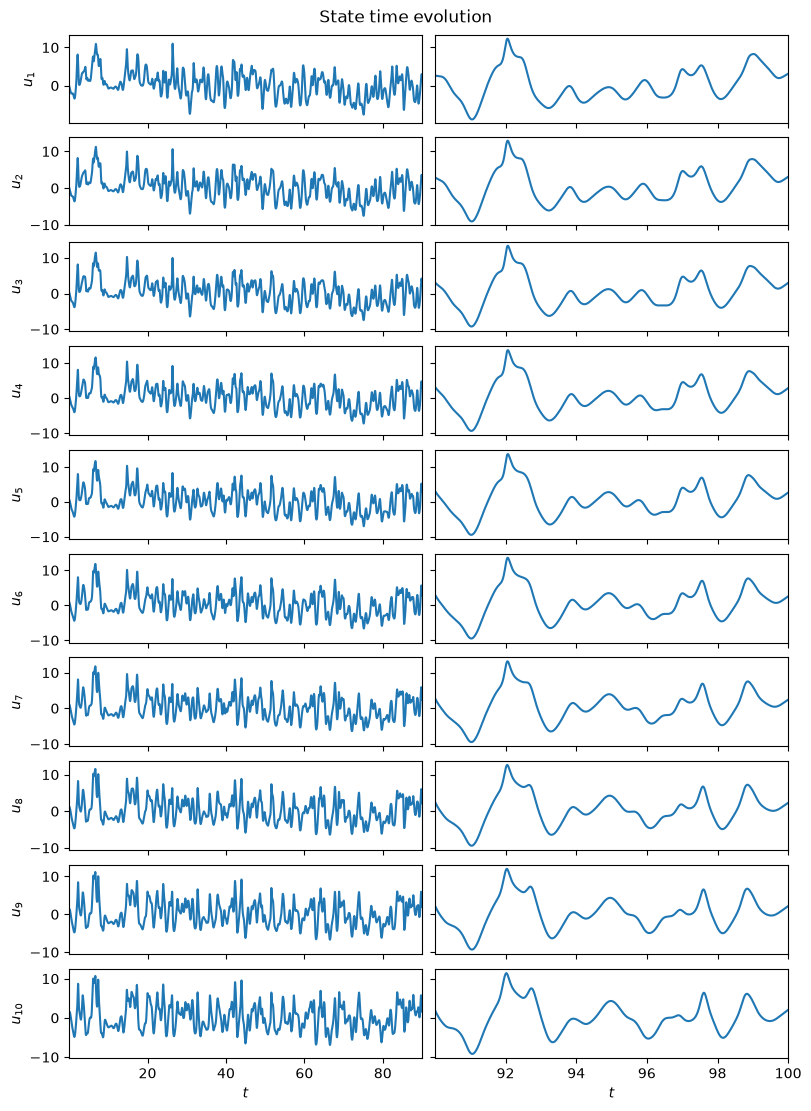

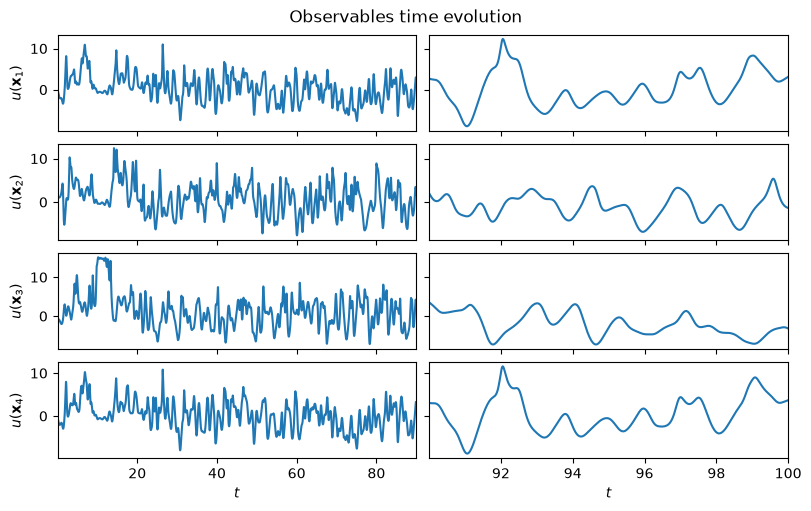

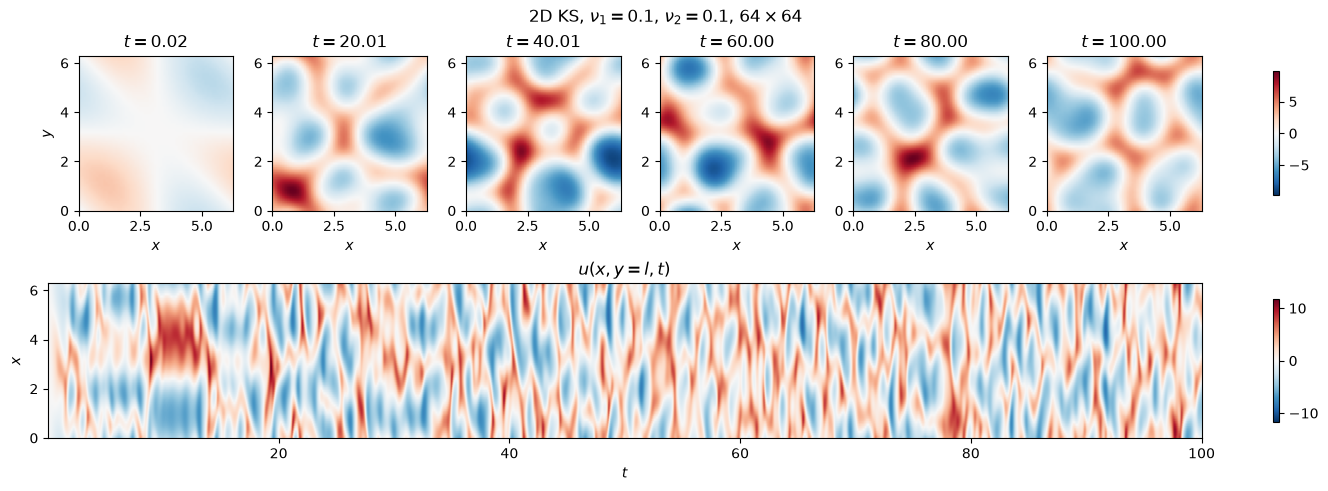

In [17]:
import matplotlib.pyplot as plt

case.visualize_history()


# Ensembles  <a class="anchor" id="fourth"></a>

`Model` supports `m`-member ensembles natively: `init_ensemble` perturbs the state (and,
optionally, selected parameters, which are augmented into the state) and stores the stacked
ensemble in the history. Everything downstream of `hist` then carries the trailing member
axis `(Nt, N, m)`.

### 1. Initialize ensemble <a class="anchor" id="fifth"></a>


In [18]:
m = 10
ensemble = case.copy()
ensemble.init_ensemble(m=m,
                       std_phi=1.,
                       est_alpha=list(case.params[-2:]),  # parameters to perturb and estimate
                       std_alpha=0.1,  # the uncertainty can also be a {name: std} dictionary
                       distribution_alpha='uniform')


### 2. Forecast ensemble <a class="anchor" id="sixth"></a>
The Model time_integrate function is parallelized to save computation time. We compare the ensemble forecast with a for loop forecast. 


{}

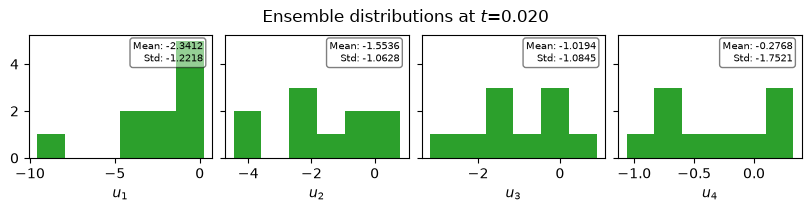

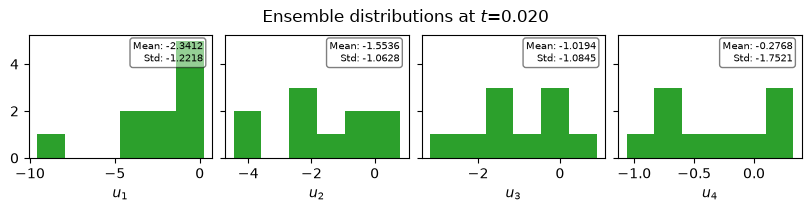

In [19]:
ensemble.visualize_state(time_indices=[0, -1],
                         max_modes=4,
                         reference_a=1.);
ensemble.alpha


## Forecast the ensemble

In [20]:
import time

def forecast(model, t_end):
    Nt = int(round((t_end - model.current_time) / model.dt))
    psi, t_ = model.time_integrate(Nt)
    model.update_history(psi, t_)

# Warm-up call: the first forecast pays the multiprocessing pool start-up cost, so it is not timed.
forecast(ensemble, ensemble.current_time + case.t_transient)

t1 = time.time()
n_tests = 10
for _ in range(n_tests):
    forecast(ensemble, ensemble.current_time + case.t_transient)  # main ensemble time-integration step
ensemble_case_time = (time.time() - t1) / n_tests

print(f'Average elapsed ensemble time over {n_tests} tests = {ensemble_case_time}')
print(f'Average elapsed time per ensemble member = {ensemble_case_time / m}')


/storage0/anovoama/dynamodels/dynamodels/physical/kuramoto_sivashinsky_2d.py:203: RuntimeWarning: overflow encountered in multiply
  return -0.5 * np.fft.fft2(vx * vx + self.aniso * vy * vy, axes=(0, 1))
/home/anovoama/.conda/envs/qlrom/lib/python3.11/site-packages/numpy/fft/_pocketfft.py:101: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)
/storage0/anovoama/dynamodels/dynamodels/physical/kuramoto_sivashinsky_2d.py:203: RuntimeWarning: invalid value encountered in multiply
  return -0.5 * np.fft.fft2(vx * vx + self.aniso * vy * vy, axes=(0, 1))
/storage0/anovoama/dynamodels/dynamodels/physical/kuramoto_sivashinsky_2d.py:222: RuntimeWarning: invalid value encountered in multiply
  vhat_next = E * vhat + f1 * Nv + 2.0 * f2 * (Na + Nb) + f3 * Nc
/storage0/anovoama/dynamodels/dynamodels/physical/kuramoto_sivashinsky_2d.py:215: RuntimeWarning: invalid value encountered in multiply
  a = E2 * vhat + Q * Nv
/storage0/anovoama/dyna

KeyboardInterrupt: 

We compare the running time of the ensemble forecast with a for-loop implementation. 

In [21]:
from dynamodels.integrator import ivp_forecast_helper, IVPIntegrator
import numpy as np

test_parallel = True  # Set to True to test the parallelization speed-up against for-loop implementation.
if type(ensemble.integrator) is IVPIntegrator:

    if not test_parallel:
        #skipp the parallelization test
        print('Skipping parallelization speed-up test.')
    else:
        print('Testing parallelization speed-up against for-loop implementation...')

        pm = ensemble

        # Same workload as one forecast_step: one window of Nt steps, per-member parameters.
        Nt = int(case.t_transient / pm.dt)
        t_all = np.round(pm.current_time + np.arange(Nt + 1) * pm.dt, pm.precision_t)
        psi0 = pm.current_state
        args = pm.governing_eqns_params
        alpha_list = pm.get_alpha()

        # --- Solve ivp for each ensemble member individually ---
        t1 = time.time()
        for mi in range(ensemble.m):
            ivp_forecast_helper(y0=psi0[:, mi],
                                fun=pm.time_derivative,
                                t=t_all,
                                params={**args, **alpha_list[mi]})
        ensemble_for_time = time.time() - t1

        print(f'Elapsed ensemble for loop time = {ensemble_for_time} >> {ensemble_case_time}.')
        print(f'Speed-up factor = {ensemble_for_time/ensemble_case_time}.')
else:
    print(f'Currently, no parallelization is available for {type(ensemble.integrator)}.')


Currently, no parallelization is available for <class 'dynamodels.integrator.DiscreteIntegrator'>.


In [22]:
ensemble.hist.shape


(10001, 4096, 10)

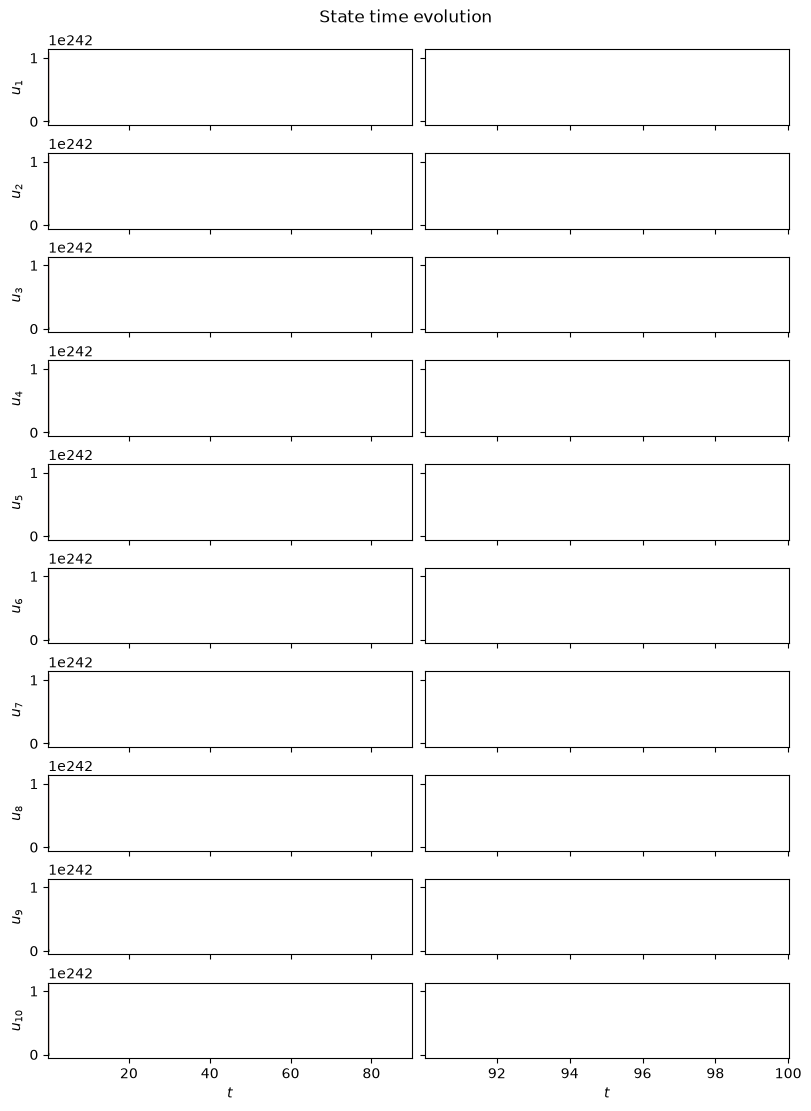

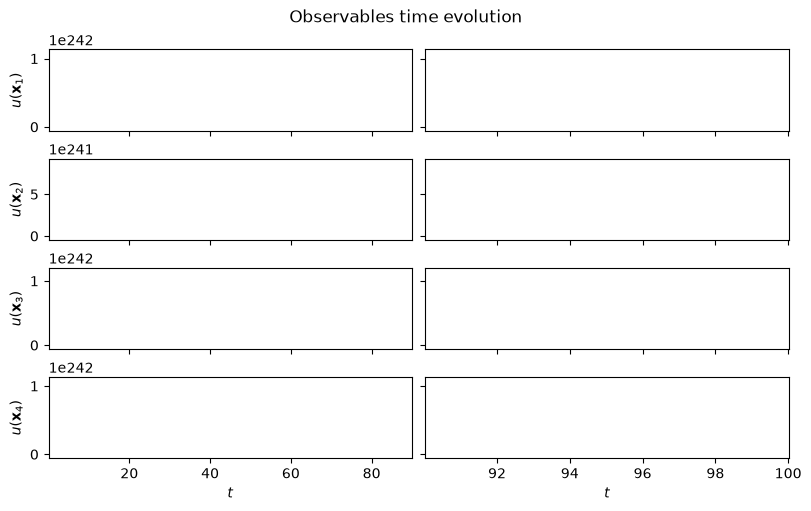

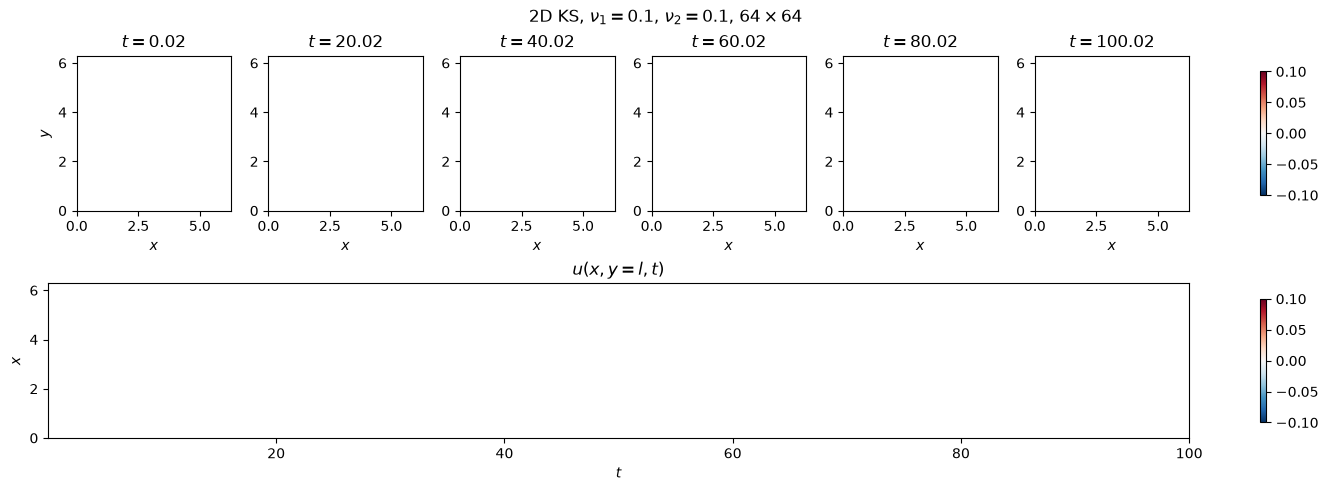

In [23]:
ensemble.visualize_history(plot_members=True, 
                           dims='all', 
                           reference_t=1., 
                           reference_a=dict(tau=0.002))

/home/anovoama/.conda/envs/qlrom/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7487: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/anovoama/.conda/envs/qlrom/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7488: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

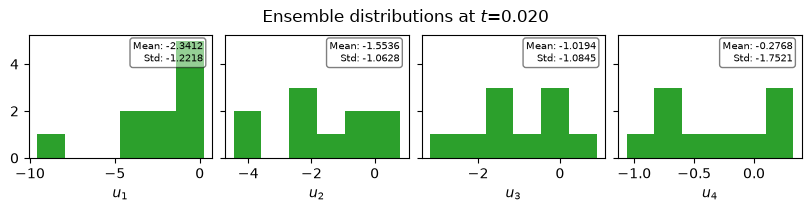

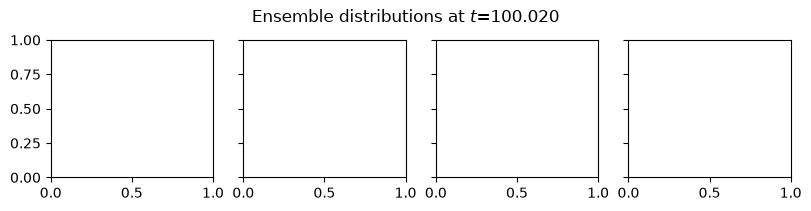

In [24]:
ensemble.visualize_state(time_indices=[0, -1], 
                         max_modes=4,
                         reference_a=1.)

In [ ]:

Nt = 5*int(ensemble.t_CR // ensemble.dt)
y_hist = ensemble.get_observable_hist(loc="all", Nt=Nt)
t_hist = ensemble.hist_t[-Nt:]


In [ ]:

ensemble.visualize_spatiotemporal_hist(averaged=False, y_hist=y_hist, t=t_hist)
ensemble.visualize_spatiotemporal_hist(averaged=True, y_hist=y_hist, t=t_hist)